# ModelPipeline & SmartRouter Deep Dive
# ModelPipeline 与 SmartRouter 深度指南

This tutorial is a comprehensive guide to the two core orchestration engines of PipelineTS:
本教程是 PipelineTS 两大核心编排引擎的全面指南：

- **ModelPipeline** — Train, evaluate, and compare multiple models with a unified API.
- **ModelPipeline** — 使用统一接口训练、评估和比较多个模型。

- **SmartRouter** — Intelligent AutoML that automatically profiles data, selects models, tunes hyperparameters, and builds ensembles.
- **SmartRouter** — 智能 AutoML，自动进行数据画像、模型选择、超参数调优和集成构建。

---

**Table of Contents / 目录:**

### Part I: ModelPipeline / 第一部分：ModelPipeline
1. Basic usage / 基本用法
2. Model filtering (`include_models`, `exclude_models`) / 模型筛选
3. Double-underscore syntax / 双下划线语法
4. PipelineConfigs / 管道配置
5. Custom scaler & metric / 自定义缩放器与指标
6. Leaderboard & model access / 排行榜与模型访问
7. Prediction intervals (`quantile`) / 预测区间
8. Multi-quantile output / 多分位数输出
9. Multi-series panel data (`id_col`) / 多序列面板数据
10. Covariates / 协变量
11. Incremental learning (`update`) / 增量学习
12. Time budget / 时间预算
13. Visualization / 可视化
14. Error resilience / 错误容错
15. Save & Load / 保存与加载

### Part II: SmartRouter / 第二部分：SmartRouter
16. Basic usage / 基本用法
17. Presets / 预设模式
18. Data profiling / 数据画像
19. Model scoring & selection / 模型评分与选择
20. Lag exploration / 滞后窗口探索
21. HPO (Optuna) / 超参数优化
22. Ensemble strategies / 集成策略
23. Search strategies / 搜索策略
24. **Pinning models (`include_models`) / 指定模型**
25. SmartRouter with panel data & covariates / 面板数据与协变量
26. SmartRouter visualization & incremental update / 可视化与增量更新
27. Full production example / 完整生产示例

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Generate example data / 生成示例数据
np.random.seed(42)
n = 200
dates = pd.date_range(start='2020-01-01', periods=n, freq='D')
values = 50 + 10 * np.sin(np.linspace(0, 6 * np.pi, n)) + np.random.randn(n) * 2
data = pd.DataFrame({'date': dates, 'value': values})

print(f"Data: {data.shape[0]} rows, {data['date'].min().date()} ~ {data['date'].max().date()}")
data.head()

Data: 200 rows, 2020-01-01 ~ 2020-07-18


,date,value
0,2020-01-01,50.993428
1,2020-01-02,50.669269
2,2020-01-03,53.178494
3,2020-01-04,55.849612
4,2020-01-05,53.230546


---
# Part I: ModelPipeline
# 第一部分：ModelPipeline

ModelPipeline is the workhorse: it takes a list of models, trains each on the same data with cross-validation, ranks them, and provides a single `predict()` call.

ModelPipeline 是核心工具：接收模型列表，在相同数据上以交叉验证训练每个模型，排名后提供统一 `predict()` 调用。

## 1. Basic Usage / 基本用法

In [2]:
from PipelineTS.pipeline import ModelPipeline

pipeline = ModelPipeline(
    time_col='date',
    target_col='value',
    lags=12,              # Input window size / 输入窗口大小
    include_models='ml',  # Use ML models (fast) / 使用 ML 模型（快速）
    quantile=0.9,         # 90% prediction interval / 90% 预测区间
    cv=3,                 # 3-fold cross validation / 3 折交叉验证
)

leaderboard = pipeline.fit(data)
leaderboard


2026-02-15 21:44:03 - ModelPipeline - INFO - Accelerator: MPS
2026-02-15 21:44:03 - ModelPipeline - INFO - Training 6 models: ['deep_forest', 'multi_output_model', 'multi_step_model', 'torch_bagging_forest', 'torch_boosting_forest', 'wide_gbrt']
2026-02-15 21:44:03 - ModelPipeline - INFO - [1/6] Fitting deep_forest...
2026-02-15 21:44:23 - ModelPipeline - INFO -   => deep_forest: metric=12.263135, train=16.44s, eval=0.35s, quantile_acc=0.458
2026-02-15 21:44:23 - ModelPipeline - INFO - [2/6] Fitting multi_output_model...
2026-02-15 21:46:04 - ModelPipeline - INFO -   => multi_output_model: metric=15.398066, train=97.08s, eval=0.62s, quantile_acc=0.625
2026-02-15 21:46:04 - ModelPipeline - INFO - [3/6] Fitting multi_step_model...
2026-02-15 21:46:17 - ModelPipeline - INFO -   => multi_step_model: metric=12.279983, train=9.05s, eval=0.60s, quantile_acc=0.708
2026-02-15 21:46:17 - ModelPipeline - INFO - [4/6] Fitting torch_bagging_forest...
2026-02-15 21:46:37 - ModelPipeline - INFO -   

Leaderboard,model,train_cost(s),eval_cost(s),metric,quantile_acc
0,wide_gbrt,90.716677,3.100677,10.062538,0.958333
1,torch_boosting_forest,11.334693,0.364083,11.491179,0.500000
2,torch_bagging_forest,16.439865,0.370515,12.262455,0.416667
3,deep_forest,16.439839,0.345595,12.263135,0.458333
4,multi_step_model,9.051184,0.601500,12.279983,0.708333
5,multi_output_model,97.077300,0.615142,15.398066,0.625000


In [3]:
# Predict with the best model / 使用最佳模型预测
result = pipeline.predict(n=15, model_name="wide_gbrt")
print(f"Best model / 最佳模型: {leaderboard.iloc[0]['model']}")
result.head()

Best model / 最佳模型: wide_gbrt


,date,value,value_lower,value_upper
0,2020-07-19,49.074619,-27.572064,72.402867
1,2020-07-20,61.448206,-15.198477,84.776454
2,2020-07-21,54.441346,-22.205337,77.769594
3,2020-07-22,54.909987,-21.736696,78.238235
4,2020-07-23,15.609952,-61.036731,38.938200


## 2. Model Filtering / 模型筛选

Control which models to train via `include_models` or `exclude_models`.

通过 `include_models` 或 `exclude_models` 控制训练哪些模型。

In [4]:
# View all available models / 查看所有可用模型
all_models = ModelPipeline.list_all_available_models()
print(f"Total models / 模型总数: {len(all_models)}")
print(all_models)

Total models / 模型总数: 27
['auto_arima', 'chronos_2', 'chronos_2_small', 'chronos_2_synth', 'd_linear', 'deep_forest', 'deepar', 'gau', 'itransformer', 'multi_output_model', 'multi_step_model', 'n_beats', 'n_hits', 'n_linear', 'patch_rnn', 'prophet', 'regressor_chain', 'srs_net', 'stacking_rnn', 'tcn', 'tft', 'tide', 'time2vec', 'torch_bagging_forest', 'torch_boosting_forest', 'transformer', 'wide_gbrt']


In [5]:
# Predefined model sets / 预定义模型集合
sets = {
    "'light' (default)": 'light',  # Balanced speed/quality / 速度与质量平衡
    "'ml'": 'ml',                  # GBDT + ensemble ML only / 仅 GBDT + 集成 ML
    "'nn'": 'nn',                  # Neural networks only / 仅神经网络
    "'all'": 'all',                # All models / 全部模型
}

for label, mode in sets.items():
    p = ModelPipeline(time_col='date', target_col='value', lags=12, include_models=mode)
    print(f"{label:20s} -> {len(p._given_models or [])} models")

# Custom list / 自定义列表
# include_models=['torch_boosting_forest', 'prophet', 'n_linear', 'tft']

'light' (default)    -> 11 models
'ml'                 -> 6 models
'nn'                 -> 15 models
'all'                -> 0 models


## 3. Double-Underscore Syntax / 双下划线语法

Pass model-specific parameters via `model_name__param=value`.

通过 `模型名__参数名=值` 传递模型特定参数。

In [6]:
pipeline_custom = ModelPipeline(
    time_col='date', target_col='value', lags=12,
    include_models=['torch_boosting_forest', 'torch_bagging_forest', 'n_linear'],
    quantile=None, cv=2,
    # Model-specific params / 模型专属参数
    torch_boosting_forest__n_trees=64,
    torch_bagging_forest__n_trees=128,
    n_linear__epochs=200,
    n_linear__patience=20,
    n_linear__verbose=False,
    n_linear__learning_rate=0.001,
    n_linear__use_gtb=True,
    n_linear__routing_mode="adaptive"
)
pipeline_custom.fit(data)


2026-02-15 21:48:30 - ModelPipeline - INFO - Accelerator: MPS
2026-02-15 21:48:30 - ModelPipeline - INFO - Training 3 models: ['n_linear', 'torch_bagging_forest', 'torch_boosting_forest']
2026-02-15 21:48:30 - ModelPipeline - INFO - [1/3] Fitting n_linear...
2026-02-15 21:49:02 - ModelPipeline - INFO -   => n_linear: metric=6.696365, train=28.14s, eval=0.70s
2026-02-15 21:49:02 - ModelPipeline - INFO - [2/3] Fitting torch_bagging_forest...
2026-02-15 21:49:17 - ModelPipeline - INFO -   => torch_bagging_forest: metric=12.262455, train=10.55s, eval=0.38s
2026-02-15 21:49:17 - ModelPipeline - INFO - [3/3] Fitting torch_boosting_forest...
2026-02-15 21:49:27 - ModelPipeline - INFO -   => torch_boosting_forest: metric=11.491179, train=6.70s, eval=0.39s
2026-02-15 21:49:27 - ModelPipeline - INFO - 
Training complete: 3 succeeded, 0 failed, 0 skipped (56.6s total)
2026-02-15 21:49:27 - ModelPipeline - INFO - 
  Rank  Model                       train_cost(s)    eval_cost(s)       Metric 
  -

Leaderboard,model,train_cost(s),eval_cost(s),metric
0,n_linear,28.137313,0.698425,6.696365
1,torch_boosting_forest,6.697761,0.391814,11.491179
2,torch_bagging_forest,10.550303,0.379843,12.262455


## 4. PipelineConfigs / 管道配置

Create multiple variants of the same model with different hyperparameters.

为同一模型创建多个不同超参数的变体。

In [7]:
from PipelineTS.pipeline import PipelineConfigs

configs = PipelineConfigs([
    ('torch_boosting_forest', 'boost_fast', {
        'init_configs': {'n_trees': 16},
        'fit_configs': {}
    }),
    ('torch_boosting_forest', 'boost_deep', {
        'init_configs': {'n_trees': 128, 'tree_depth': 7},
        'fit_configs': {}
    }),
])

pipe_conf = ModelPipeline(
    time_col='date', target_col='value', lags=12,
    include_models=['torch_boosting_forest'], configs=configs,
    quantile=None, cv=2,
)
pipe_conf.fit(data)

,model_name,model_name_after_rename,model_configs
0,torch_boosting_forest,boost_fast,"{'init_configs': {'n_trees': 16}, 'fit_configs': {}, 'predict_configs': {}, 'pipeline_configs': {}}"
1,torch_boosting_forest,boost_deep,"{'init_configs': {'n_trees': 128, 'tree_depth': 7}, 'fit_configs': {}, 'predict_configs': {}, 'pipeline_configs': {}}"



2026-02-15 21:49:27 - ModelPipeline - INFO - Accelerator: MPS
2026-02-15 21:49:27 - ModelPipeline - INFO - Training 2 models: ['boost_fast', 'boost_deep']
2026-02-15 21:49:27 - ModelPipeline - INFO - [1/2] Fitting boost_fast...
2026-02-15 21:49:37 - ModelPipeline - INFO -   => boost_fast: metric=11.682914, train=5.86s, eval=0.47s
2026-02-15 21:49:37 - ModelPipeline - INFO - [2/2] Fitting boost_deep...
2026-02-15 21:49:50 - ModelPipeline - INFO -   => boost_deep: metric=11.734172, train=9.39s, eval=0.43s
2026-02-15 21:49:50 - ModelPipeline - INFO - 
Training complete: 2 succeeded, 0 failed, 0 skipped (22.7s total)
2026-02-15 21:49:50 - ModelPipeline - INFO - 
  Rank  Model                       train_cost(s)    eval_cost(s)       Metric 
  -----------------------------------------------------------------------------
 *1    boost_fast                      5.8595       0.4730      11.6829 
  2    boost_deep                      9.3947       0.4283      11.7342 


Leaderboard,model,train_cost(s),eval_cost(s),metric
0,boost_fast,5.859531,0.472966,11.682914
1,boost_deep,9.394661,0.428298,11.734172


## 5. Custom Scaler & Metric / 自定义缩放器与指标

In [8]:
from sklearn.preprocessing import StandardScaler
from PipelineTS.spinesTS.metrics import rmse

pipe_custom = ModelPipeline(
    time_col='date', target_col='value', lags=12,
    include_models=['torch_boosting_forest', 'torch_bagging_forest'],
    scaler=StandardScaler(),         # Custom scaler / 自定义缩放器
    metric=rmse,                      # RMSE instead of MAE / 使用 RMSE 替代 MAE
    metric_less_is_better=True,
    quantile=None, cv=2,
)
pipe_custom.fit(data)


2026-02-15 21:49:50 - ModelPipeline - INFO - Accelerator: MPS
2026-02-15 21:49:50 - ModelPipeline - INFO - Training 2 models: ['torch_bagging_forest', 'torch_boosting_forest']
2026-02-15 21:49:50 - ModelPipeline - INFO - [1/2] Fitting torch_bagging_forest...
2026-02-15 21:50:04 - ModelPipeline - INFO -   => torch_bagging_forest: metric=12.729848, train=10.19s, eval=0.33s
2026-02-15 21:50:04 - ModelPipeline - INFO - [2/2] Fitting torch_boosting_forest...
2026-02-15 21:50:14 - ModelPipeline - INFO -   => torch_boosting_forest: metric=13.278303, train=6.48s, eval=0.32s
2026-02-15 21:50:14 - ModelPipeline - INFO - 
Training complete: 2 succeeded, 0 failed, 0 skipped (23.8s total)
2026-02-15 21:50:14 - ModelPipeline - INFO - 
  Rank  Model                       train_cost(s)    eval_cost(s)       Metric 
  -----------------------------------------------------------------------------
 *1    torch_bagging_forest           10.1950       0.3305      12.7298 
  2    torch_boosting_forest       

Leaderboard,model,train_cost(s),eval_cost(s),metric
0,torch_bagging_forest,10.194970,0.330475,12.729848
1,torch_boosting_forest,6.480096,0.320236,13.278303


## 6. Leaderboard & Model Access / 排行榜与模型访问

In [9]:
# Leaderboard is a DataFrame / 排行榜是 DataFrame
print("Leaderboard columns / 排行榜列名:", pipeline.leader_board_.columns.tolist())
print()

# Get the best trained model object / 获取最佳已训练模型对象
best_model = pipeline.get_model()
print(f"Best model type / 最佳模型类型: {type(best_model).__name__}")

# Get a specific model / 获取指定模型
second_model_name = pipeline.leader_board_.iloc[1]['model']
specific_model = pipeline.get_model(second_model_name)
print(f"Second model / 第二模型: {second_model_name}")

# Get all configs / 获取全部配置
configs = pipeline.get_model_all_configs()
print(f"Config keys / 配置键: {list(configs.keys())[:5]}...")

Leaderboard columns / 排行榜列名: ['model', 'train_cost(s)', 'eval_cost(s)', 'metric', 'quantile_acc']

Best model type / 最佳模型类型: WideGBRTModel
Second model / 第二模型: torch_boosting_forest
Config keys / 配置键: ['model_configs', 'lags', 'quantile', 'time_col', 'target_col']...


In [10]:
# Predict with a specific model / 使用指定模型预测
result_second = pipeline.predict(n=10, model_name=second_model_name)
result_second.head()

,date,value,value_lower,value_upper
0,2020-07-19,51.882545,39.633484,61.556698
1,2020-07-20,51.318521,39.069460,60.992674
2,2020-07-21,54.404274,42.155214,64.078428
3,2020-07-22,55.483773,43.234712,65.157926
4,2020-07-23,53.794485,41.545425,63.468639


## 7. Prediction Intervals / 预测区间

In [11]:
# quantile=0.9 was set at init → predict returns _lower/_upper columns
# quantile=0.9 在初始化时设置 → predict 返回 _lower/_upper 列
result_interval = pipeline.predict(15)
print("Columns / 列名:", result_interval.columns.tolist())
result_interval.head()

Columns / 列名: ['date', 'value', 'value_lower', 'value_upper']


,date,value,value_lower,value_upper
0,2020-07-19,49.074619,-27.572064,72.402867
1,2020-07-20,61.448206,-15.198477,84.776454
2,2020-07-21,54.441346,-22.205337,77.769594
3,2020-07-22,54.909987,-21.736696,78.238235
4,2020-07-23,15.609952,-61.036731,38.938200


## 8. Multi-Quantile Output / 多分位数输出

In [12]:
# Predict at multiple coverage levels simultaneously
# 同时预测多个覆盖水平
result_mq = pipeline.predict_quantiles(n=10, levels=[0.5, 0.8, 0.95])
print("Multi-quantile columns / 多分位数列:")
for c in result_mq.columns:
    print(f"  {c}")
result_mq.head()

Multi-quantile columns / 多分位数列:
  date
  value
  value_q0.5_lower
  value_q0.5_upper
  value_q0.8_lower
  value_q0.8_upper
  value_q0.95_lower
  value_q0.95_upper


,date,value,value_q0.5_lower,value_q0.5_upper,value_q0.8_lower,value_q0.8_upper,value_q0.95_lower,value_q0.95_upper
0,2020-07-19,49.074619,34.117957,53.447948,-7.297544,62.188967,-43.701605,78.644775
1,2020-07-20,61.448206,46.491544,65.821536,5.076043,74.562554,-31.328017,91.018363
2,2020-07-21,54.441346,39.484684,58.814676,-1.930817,67.555694,-38.334878,84.011503
3,2020-07-22,54.909987,39.953326,59.283317,-1.462175,68.024336,-37.866236,84.480144
4,2020-07-23,15.609952,0.653290,19.983282,-40.762211,28.724300,-77.166271,45.180109


## 9. Multi-Series Panel Data / 多序列面板数据

In [13]:
# Create panel data / 创建面板数据
panel_dfs = []
for sid in ['A', 'B', 'C']:
    v = np.random.uniform(30, 70) + 8 * np.sin(np.linspace(0, 4*np.pi, 150)) + np.random.randn(150)*2
    panel_dfs.append(pd.DataFrame({
        'date': pd.date_range('2020-01-01', periods=150, freq='D'),
        'value': v, 'store': sid
    }))
panel_data = pd.concat(panel_dfs, ignore_index=True)

pipe_panel = ModelPipeline(
    time_col='date', target_col='value', lags=12,
    id_col='store',                  # Panel mode / 面板模式
    include_models=['torch_boosting_forest'],
    quantile=0.9, cv=2,
)
pipe_panel.fit(panel_data)
panel_pred = pipe_panel.predict(n=5)

print(f"Panel prediction: {panel_pred.shape[0]} rows, stores: {panel_pred['store'].unique().tolist()}")
panel_pred


2026-02-15 21:50:15 - ModelPipeline - INFO - Accelerator: MPS
2026-02-15 21:50:15 - ModelPipeline - INFO - Multi-series mode: 3 series detected (id_col='store')
2026-02-15 21:50:15 - ModelPipeline - INFO - Training 1 models: ['torch_boosting_forest']
2026-02-15 21:50:15 - ModelPipeline - INFO - [1/1] Fitting torch_boosting_forest...
2026-02-15 21:50:36 - ModelPipeline - INFO -   => torch_boosting_forest: metric=10.947804, train=16.73s, eval=0.59s, quantile_acc=0.431
2026-02-15 21:50:36 - ModelPipeline - INFO - 
Training complete: 1 succeeded, 0 failed, 0 skipped (20.6s total)
2026-02-15 21:50:36 - ModelPipeline - INFO - 
  Rank  Model                       train_cost(s)    eval_cost(s)       Metric     QAcc 
  --------------------------------------------------------------------------------------
 *1    torch_boosting_forest          16.7344       0.5905      10.9478       0.4306 


Panel prediction: 15 rows, stores: ['A', 'B', 'C']


,date,value,value_lower,value_upper,store
0,2020-05-30,52.778111,42.490143,64.846820,A
1,2020-05-31,54.234083,43.946114,66.302792,A
2,2020-06-01,54.530727,44.242759,66.599436,A
3,2020-06-02,54.111098,43.823129,66.179807,A
4,2020-06-03,55.750252,45.462284,67.818961,A
5,2020-05-30,42.488785,30.636306,56.392805,B
6,2020-05-31,42.747499,30.895021,56.651519,B
7,2020-06-01,42.373471,30.520992,56.277490,B
8,2020-06-02,43.537965,31.685486,57.441985,B
9,2020-06-03,45.345642,33.493163,59.249662,B


## 10. Covariates / 协变量

In [14]:
# Add covariates to data / 向数据添加协变量
cov_data = data.copy()
cov_data['holiday'] = np.random.choice([0, 1], size=len(data), p=[0.9, 0.1])
cov_data['temperature'] = 15 + 10 * np.sin(np.linspace(0, 2*np.pi, len(data))) + np.random.randn(len(data))

pipe_cov = ModelPipeline(
    time_col='date', target_col='value', lags=12,
    known_covariates=['holiday'],         # Future known / 未来已知
    past_covariates=['temperature'],      # Historical only / 仅历史
    include_models=['torch_boosting_forest', 'prophet'],
    quantile=0.9, cv=2,
)
pipe_cov.fit(cov_data)

# Provide future covariates at predict time / 预测时提供未来协变量
future = pd.DataFrame({'holiday': [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]})
pipe_cov.predict(n=10, future_covariates=future).head()


2026-02-15 21:50:36 - ModelPipeline - INFO - Accelerator: MPS
2026-02-15 21:50:36 - ModelPipeline - INFO - Training 2 models: ['prophet', 'torch_boosting_forest']
2026-02-15 21:50:36 - ModelPipeline - INFO - [1/2] Fitting prophet...
2026-02-15 21:50:40 - ModelPipeline - INFO -   => prophet: metric=13.850894, train=1.08s, eval=0.20s, quantile_acc=0.458
2026-02-15 21:50:40 - ModelPipeline - INFO - [2/2] Fitting torch_boosting_forest...
2026-02-15 21:50:57 - ModelPipeline - INFO -   => torch_boosting_forest: metric=9.482962, train=12.81s, eval=0.35s, quantile_acc=1.000
2026-02-15 21:50:57 - ModelPipeline - INFO - 
Training complete: 2 succeeded, 0 failed, 0 skipped (21.0s total)
2026-02-15 21:50:57 - ModelPipeline - INFO - 
  Rank  Model                       train_cost(s)    eval_cost(s)       Metric     QAcc 
  --------------------------------------------------------------------------------------
 *1    torch_boosting_forest          12.8149       0.3470       9.4830       1.0000 
  2 

,date,value,value_lower,value_upper
0,2020-07-19,45.807164,24.278330,59.207808
1,2020-07-20,44.278320,22.749486,57.678964
2,2020-07-21,52.017852,30.489017,65.418495
3,2020-07-22,55.872838,34.344004,69.273482
4,2020-07-23,55.889821,34.360987,69.290465


## 11. Incremental Learning / 增量学习

In [15]:
# Initial fit / 初始训练
pipe_inc = ModelPipeline(
    time_col='date', target_col='value', lags=12,
    include_models=['torch_boosting_forest'], quantile=None, cv=2,
)
pipe_inc.fit(data.iloc[:150])
print("Before update / 更新前:", pipe_inc.predict(3)['value'].values)

# Incremental update / 增量更新
pipe_inc.update(data.iloc[150:])
print("After update / 更新后: ", pipe_inc.predict(3)['value'].values)


2026-02-15 21:50:57 - ModelPipeline - INFO - Accelerator: MPS
2026-02-15 21:50:57 - ModelPipeline - INFO - Training 1 models: ['torch_boosting_forest']
2026-02-15 21:50:57 - ModelPipeline - INFO - [1/1] Fitting torch_boosting_forest...
2026-02-15 21:51:07 - ModelPipeline - INFO -   => torch_boosting_forest: metric=9.301107, train=6.79s, eval=0.33s
2026-02-15 21:51:07 - ModelPipeline - INFO - 
Training complete: 1 succeeded, 0 failed, 0 skipped (10.4s total)
2026-02-15 21:51:07 - ModelPipeline - INFO - 
  Rank  Model                       train_cost(s)    eval_cost(s)       Metric 
  -----------------------------------------------------------------------------
 *1    torch_boosting_forest           6.7882       0.3295       9.3011 


Before update / 更新前: [58.97332012 57.90662588 58.90281951]



2026-02-15 21:51:14 - ModelPipeline - INFO -   Updated: torch_boosting_forest


After update / 更新后:  [51.88254454 51.31852082 54.40427447]


## 12. Time Budget / 时间预算

In [16]:
pipe_timed = ModelPipeline(
    time_col='date', target_col='value', lags=12,
    include_models='ml',
    time_limit=30,         # 30 seconds total budget / 总共 30 秒预算
    quantile=None, cv=2,
)
pipe_timed.fit(data)

print(f"Completed models / 完成的模型: {len(pipe_timed.leader_board_)}")
print(f"Failed / 失败: {len(pipe_timed.failed_models)}")
print(f"Skipped / 跳过: {len(pipe_timed.skipped_models)}")

if pipe_timed.skipped_models:
    print("Skipped details / 跳过详情:")
    for s in pipe_timed.skipped_models:
        print(f"  {s}")


2026-02-15 21:51:14 - ModelPipeline - INFO - Accelerator: MPS
2026-02-15 21:51:14 - ModelPipeline - INFO - Time budget: 30s
2026-02-15 21:51:14 - ModelPipeline - INFO - Training 6 models: ['deep_forest', 'multi_output_model', 'multi_step_model', 'torch_bagging_forest', 'torch_boosting_forest', 'wide_gbrt']
2026-02-15 21:51:14 - ModelPipeline - INFO - [1/6] Fitting deep_forest... | remaining 30s
2026-02-15 21:51:28 - ModelPipeline - INFO -   => deep_forest: metric=12.263135, train=10.41s, eval=0.39s
2026-02-15 21:51:28 - ModelPipeline - INFO - [2/6] Fitting multi_output_model... | remaining 16s
2026-02-15 21:52:03 - ModelPipeline - INFO -   => multi_output_model: metric=15.095399, train=31.18s, eval=0.72s
2026-02-15 21:52:03 - ModelPipeline - WARNING - Time budget exhausted after 49.2s. Skipping 4 remaining model(s): ['multi_step_model', 'torch_bagging_forest', 'torch_boosting_forest', 'wide_gbrt']
2026-02-15 21:52:03 - ModelPipeline - INFO - 
Training complete: 2 succeeded, 0 failed, 

Completed models / 完成的模型: 2
Failed / 失败: 0
Skipped / 跳过: 4
Skipped details / 跳过详情:
  ('multi_step_model', 'time_limit_exceeded')
  ('torch_bagging_forest', 'time_limit_exceeded')
  ('torch_boosting_forest', 'time_limit_exceeded')
  ('wide_gbrt', 'time_limit_exceeded')


## 13. Visualization / 可视化

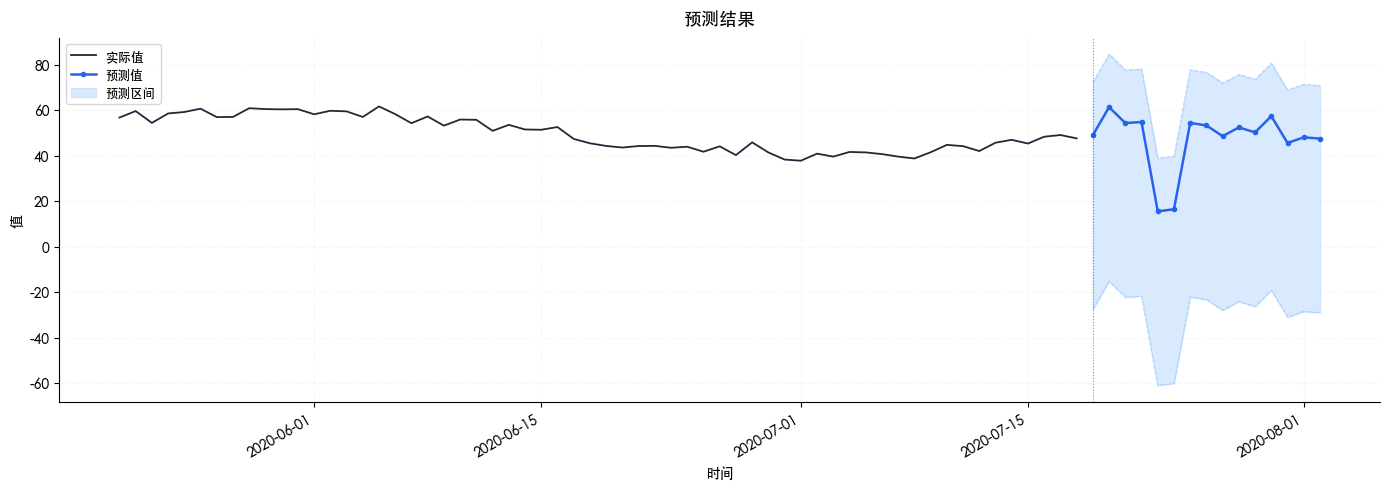

In [17]:
# One-line forecast plot / 一行代码预测图
fig = pipeline.plot(n=15, history_tail=60, lang='zh')

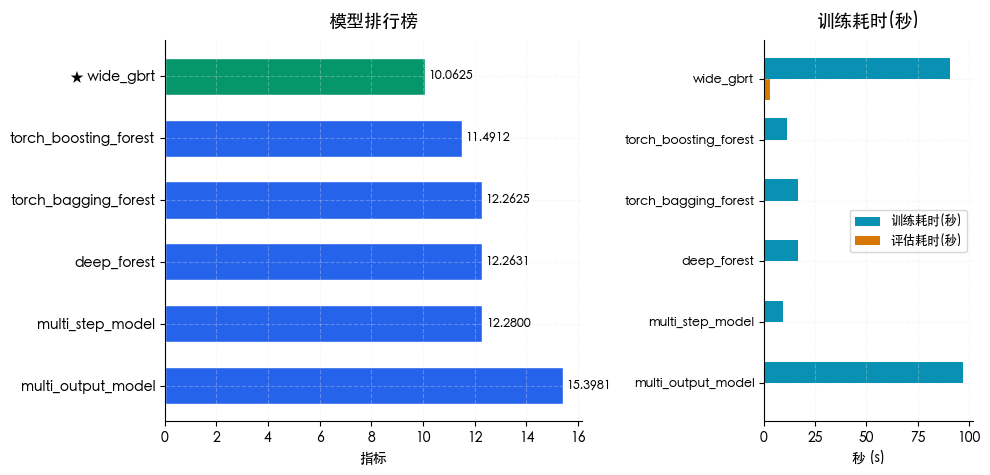

In [18]:
# Leaderboard chart / 排行榜图
fig = pipeline.plot_leaderboard(lang='zh')

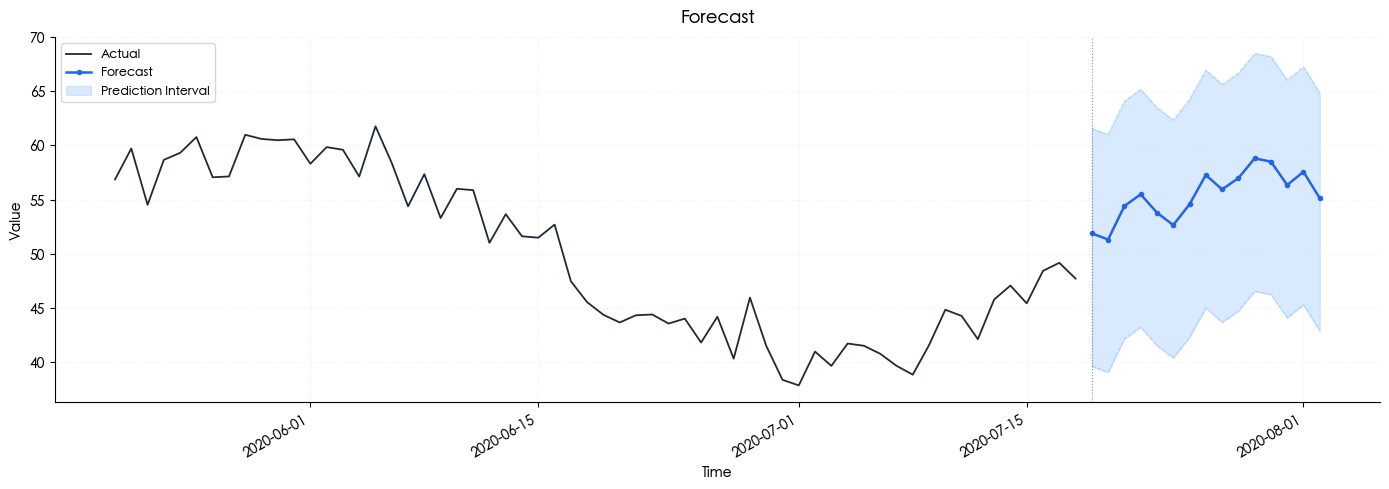

In [19]:
# Use a specific model / 指定模型
fig = pipeline.plot(n=15, model_name=second_model_name, history_tail=60, lang='en')

## 14. Error Resilience / 错误容错

If a model fails during training, the pipeline continues with remaining models.

如果某个模型在训练过程中失败，管道会继续训练其余模型。

In [20]:
# Accessing failure/skip info after fit / 拟合后访问失败/跳过信息
print(f"Failed models / 失败模型: {pipeline.failed_models}")
print(f"Skipped models / 跳过模型: {pipeline.skipped_models}")

Failed models / 失败模型: []
Skipped models / 跳过模型: []


## 15. Save & Load / 保存与加载

In [21]:
from PipelineTS.io import save_model, load_model

# Save with metadata or not
# save_model('model.pts', model, metadata={'author': 'bk'})

# Load with integrity check (default)
# loaded = load_model('my_pipeline.pts')
# loaded.predict(10)

# Inspect without loading
# info = get_file_info('my_pipeline.pts')  # header, sections, checksums

# Full integrity verification
# result = verify_file('my_pipeline.pts')  # {'valid': True, ...}

print("Uncomment the lines above to save/load. / 取消注释以保存/加载。")

Uncomment the lines above to save/load. / 取消注释以保存/加载。


---
# Part II: SmartRouter
# 第二部分：SmartRouter

SmartRouter is the intelligent layer on top of ModelPipeline. It automates the entire ML pipeline:

SmartRouter 是 ModelPipeline 之上的智能层，自动化整个 ML 流程：

```
Data → Profile → Preprocess → Score Models → Select Candidates
     → Screen → Explore Lags → HPO → Full Training → Ensemble → Predict
```

| Step / 步骤 | What it does / 功能 |
|---|---|
| **Data Profiling** | Analyze stationarity, trend, seasonality, noise, autocorrelation, regime changes / 分析平稳性、趋势、季节性、噪声、自相关、体制变化 |
| **Preprocessing** | Auto handle missing values, outliers, irregular frequency / 自动处理缺失值、异常值、不规则频率 |
| **Model Scoring** | Score all 26 models based on data characteristics / 基于数据特征对所有 26 个模型评分 |
| **Model Selection** | 5-category diversity: statistic, ML, NN-light, NN-medium, NN-heavy / 五类多样性选择 |
| **Quick Screening** | Fast holdout screening to eliminate weak candidates / 快速留出法筛选弱候选 |
| **Lag Exploration** | Test multiple lag windows, pick optimal / 测试多个滞后窗口，选择最优 |
| **HPO** | Optuna hyperparameter tuning per model / 每模型 Optuna 超参数调优 |
| **Full Training** | Train selected models with optimal config / 使用最优配置训练选中模型 |
| **Ensemble** | Combine top-K models (weighted avg, median, stacking, multi-stack) / 组合 top-K 模型 |

## 16. SmartRouter Basic Usage / 基本用法

In [22]:
from PipelineTS.pipeline import SmartRouter

# Minimal: just time_col and target_col
# 最简：仅需 time_col 和 target_col
router = SmartRouter(
    time_col='date',
    target_col='value',
)
router.fit(data)

pred = router.predict(n=15)
print(f"Prediction shape / 预测形状: {pred.shape}")
pred.head()


2026-02-15 21:52:05 - SmartRouter - INFO - Accelerator: MPS
2026-02-15 21:52:05 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 21:52:05 - SmartRouter - INFO -   [RouteStep 1/6] 📊 Data Profiling                   0.0s
2026-02-15 21:52:05 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 21:52:05 - SmartRouter - INFO -   Rows: 200  |  Freq: D  |  Regular: True
  Stationarity: stationary (d=0)
  Trend: 0.055  |  Seasonality: 0.883  |  Noise: 0.972
  Autocorr(1): 0.926  |  Autocorr(2): 0.914  |  CV: 0.144
  Seasonalities: 3  |  Regime changes: 32
  Missing: 0.0%  |  Outliers: 0.0%  |  Has negative: False  Dominant periods: [67, 100, 6]
2026-02-15 21:52:05 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 21:52:05 - SmartRouter - INFO -   [RouteStep 2/6] 🎯 Strategy & Model Selection       0.0s
2026-02-15 21:52:05 - SmartRouter - INFO - ══════════════════

Prediction shape / 预测形状: (15, 2)


,date,value
0,2020-07-11,40.248550
1,2020-07-12,39.714864
2,2020-07-13,41.478711
3,2020-07-14,43.656437
4,2020-07-15,40.476342


## 17. Presets / 预设模式

SmartRouter provides 4 quality presets that configure multiple parameters at once.

SmartRouter 提供 4 种质量预设，一次配置多个参数。

| Preset / 预设 | max_models | cv | search | ensemble |
|---|---|---|---|---|
| `'fast'` | 3 | 3 | basic | none |
| `'medium_quality'` (default) | 5 | 5 | auto | auto |
| `'high_quality'` | 8 | 5 | thorough | weighted_avg |
| `'best_quality'` | 15 | 5 | thorough | weighted_avg (top-5) |

In [23]:
# Fast preset: quick results / 快速预设：快速出结果
router_fast = SmartRouter(
    time_col='date', target_col='value',
    preset='fast',
)
router_fast.fit(data)

print(f"Models trained / 训练模型数: {len(router_fast.leader_board_)}")
print(f"Ensemble / 集成: {router_fast.ensemble_}")
router_fast.leader_board_


2026-02-15 22:04:24 - SmartRouter - INFO - Preset 'fast': max_models=3, cv=3, search=basic, ensemble=none
2026-02-15 22:04:24 - SmartRouter - INFO - Accelerator: MPS
2026-02-15 22:04:24 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 22:04:24 - SmartRouter - INFO -   [RouteStep 1/4] 📊 Data Profiling                   0.0s
2026-02-15 22:04:24 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 22:04:24 - SmartRouter - INFO -   Rows: 200  |  Freq: D  |  Regular: True
  Stationarity: stationary (d=0)
  Trend: 0.055  |  Seasonality: 0.883  |  Noise: 0.972
  Autocorr(1): 0.926  |  Autocorr(2): 0.914  |  CV: 0.144
  Seasonalities: 3  |  Regime changes: 32
  Missing: 0.0%  |  Outliers: 0.0%  |  Has negative: False  Dominant periods: [67, 100, 6]
2026-02-15 22:04:24 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 22:04:24 - SmartRouter - INFO -   [RouteStep 

Models trained / 训练模型数: 3
Ensemble / 集成: None


Leaderboard,model,train_cost(s),eval_cost(s),metric
0,n_beats,613.443837,0.383038,5.284486
1,tcn,291.152119,0.361484,5.861116
2,torch_boosting_forest,7.426972,0.389219,7.420598


In [24]:
# High quality with time limit / 高质量 + 时间限制
router_hq = SmartRouter(
    time_col='date', target_col='value',
    preset='high_quality',
    time_limit=120,        # 2-minute budget / 2 分钟预算
)
router_hq.fit(data)
router_hq.leader_board_


2026-02-15 22:19:47 - SmartRouter - INFO - Preset 'high_quality': max_models=8, cv=5, search=thorough, ensemble=weighted_avg
2026-02-15 22:19:47 - SmartRouter - INFO - Accelerator: MPS
2026-02-15 22:19:48 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 22:19:48 - SmartRouter - INFO -   [RouteStep 1/6] 📊 Data Profiling                   0.0s
2026-02-15 22:19:48 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 22:19:48 - SmartRouter - INFO -   Rows: 200  |  Freq: D  |  Regular: True
  Stationarity: stationary (d=0)
  Trend: 0.055  |  Seasonality: 0.883  |  Noise: 0.972
  Autocorr(1): 0.926  |  Autocorr(2): 0.914  |  CV: 0.144
  Seasonalities: 3  |  Regime changes: 32
  Missing: 0.0%  |  Outliers: 0.0%  |  Has negative: False  Dominant periods: [67, 100, 6]
2026-02-15 22:19:48 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 22:19:48 - SmartRouter - I

Leaderboard,model,train_cost(s),eval_cost(s),metric
0,auto_arima,3.371734,0.193303,3.942756


## 18. Data Profiling / 数据画像

After `fit()`, inspect the data profile that drove all routing decisions.

`fit()` 后，检查驱动所有路由决策的数据画像。

In [25]:
# Data profile summary / 数据画像摘要
profile = router.profile_
print(profile)

print(f"\nKey insights / 关键洞察:")
print(f"  Frequency / 频率: {profile.freq}")
print(f"  Stationarity / 平稳性: {profile.stationarity}")
print(f"  Trend strength / 趋势强度: {profile.trend_strength:.3f}")
print(f"  Seasonality strength / 季节性强度: {profile.seasonality_strength:.3f}")
print(f"  Noise ratio / 噪声比: {profile.noise_ratio:.3f}")
print(f"  Autocorr lag-1 / 滞后-1 自相关: {profile.autocorr_lag1:.3f}")
print(f"  Dominant periods / 主周期: {profile.dominant_periods}")
print(f"  Regime changes / 体制变化: {profile.regime_changes}")

DataProfile(
  n_rows=200,
  freq='D',
  freq_timedelta=Timedelta('1 days 00:00:00'),
  is_regular=True,
  dominant_periods=[67, 100, 6],
  stationarity='stationary',
  suggested_d=0,
  mean=49.92,
  std=7.168,
  cv=0.1436,
  skewness=-0.01096,
  kurtosis=-1.369,
  has_negative=False,
  pct_missing=0,
  pct_outlier=0,
  noise_ratio=0.972,
  trend_strength=0.0553,
  seasonality_strength=0.8827,
  autocorr_lag1=0.9255,
  autocorr_lag2=0.9142,
  n_seasonalities=3,
  regime_changes=32,
  n_series=1,
)

Key insights / 关键洞察:
  Frequency / 频率: D
  Stationarity / 平稳性: stationary
  Trend strength / 趋势强度: 0.055
  Seasonality strength / 季节性强度: 0.883
  Noise ratio / 噪声比: 0.972
  Autocorr lag-1 / 滞后-1 自相关: 0.926
  Dominant periods / 主周期: [67, 100, 6]
  Regime changes / 体制变化: 32


## 19. Model Scoring & Selection / 模型评分与选择

SmartRouter scores all 26 models based on data characteristics and provides transparent scoring reasons.

SmartRouter 基于数据特征对所有 26 个模型评分，并提供透明的评分原因。

In [26]:
# View model scores / 查看模型评分
scores = router.model_scores_

# Top 10 scored models / 评分前 10 的模型
top10 = sorted(scores.items(), key=lambda x: x[1]['total'], reverse=True)[:10]
for name, info in top10:
    reasons_str = ', '.join(f"{r}({d:+.0f})" for r, d in info['reasons'] if r != 'base')
    print(f"  {name:20s} score={info['total']:.0f}  [{reasons_str}]")

  tft                  score=91  [medium_series(n=200): heavy NN viable(+10), strong_seasonality(0.88): seasonal specialist(+10), strong_autocorr: attention/temporal(+5), multi_seasonal(n=3): complex pattern(+8), regime_changes: attention handles shifts(+3), GTB-capable: adaptive routing benefits complex data(+5)]
  torch_boosting_forest score=90  [medium_series(n=200): ML good(+12), high_noise(0.97): robust tree model(+8), regime_changes(32): tree handles discontinuities(+3), tree: proven baseline performer(+3), speed: fast GPU-accelerated tree(+3), boosting: robust for noisy large data(+3), torch_boosting_forest: GPU amortization on medium+ data(+3), torch_boosting_forest: end-to-end feature learning(+3), torch_boosting_forest: differentiable boosting(+2)]
  n_beats              score=90  [medium_series(n=200): medium NN sweet spot(+12), strong_seasonality(0.88): seasonal specialist(+10), high_noise: regularized NN(+5), multi_seasonal(n=3): complex pattern(+8), GTB-capable: adaptive 

In [27]:
# View the selected strategy / 查看选中的策略
strategy = router.strategy
print("Selected strategy / 选中策略:")
print(f"  Models / 模型: {strategy['models']}")
print(f"  Lags / 滞后: {strategy['lags']}")
print(f"  Scaler / 缩放器: {type(strategy['scaler']).__name__}")
print(f"  GBDT diff / GBDT 差分: {strategy['gbdt_differential_n']}")
print(f"  Feature engineering / 特征工程: {strategy['feature_engineering']}")

Selected strategy / 选中策略:
  Models / 模型: ['tft', 'n_beats', 'tcn', 'torch_boosting_forest', 'auto_arima']
  Lags / 滞后: 4
  Scaler / 缩放器: MinMaxScaler
  GBDT diff / GBDT 差分: 0
  Feature engineering / 特征工程: {'routing_mode': 'adaptive', 'prophet_use_lag_features': True, 'prophet_seasonality_mode': 'auto'}


## 20. Lag Exploration / 滞后窗口探索

When `search_strategy='auto'` or `'thorough'`, SmartRouter tests 2-3 lag candidates and picks the best via holdout evaluation.

当 `search_strategy='auto'` 或 `'thorough'` 时，SmartRouter 测试 2-3 个候选滞后窗口，通过留出验证选择最优。

In [28]:
# Lag exploration results (if applicable)
# 滞后窗口探索结果（如果有的话）
if router._lag_exploration_results:
    print("Lag exploration results / 滞后窗口探索结果:")
    for lag, metric in router._lag_exploration_results.items():
        marker = ' ← selected / 已选择' if lag == router.strategy_['lags'] else ''
        metrics = {k: round(v, 4) for k, v in metric.items()}
        print(f"  lags={lag}: metric={metrics}{marker}")
else:
    print(f"Lag was directly computed: {router.strategy_['lags']}")
    print("(Lag exploration runs with 'auto' or 'thorough' search strategy)")

Lag exploration results / 滞后窗口探索结果:
  lags=tft: metric={4: 1.7473, 6: 3.0082, 8: 6.636}
  lags=n_beats: metric={4: 2.7827, 6: 2.9485, 8: 7.0036}
  lags=tcn: metric={4: 1.8471, 6: 3.4195, 8: 3.0785}
  lags=torch_boosting_forest: metric={4: 2.9341, 6: 6.4488, 8: 11.4372}
  lags=auto_arima: metric={4: 3.9428, 6: 4.7049, 8: 5.9437}


## 21. Optuna HPO / 超参数优化

Enable Optuna-based hyperparameter optimization between lag exploration and full training.

在滞后窗口探索和完整训练之间启用基于 Optuna 的超参数优化。

In [29]:
router_hpo = SmartRouter(
    time_col='date', target_col='value',
    preset='fast',
    hpo_strategy='quick',           # 'none', 'quick' (5 trials), 'full'
    hpo_n_trials=5,                 # Trials per model / 每模型试验数
    hpo_timeout_per_model=30,       # Max seconds per model / 每模型最大秒数
)
router_hpo.fit(data)

# View HPO results / 查看 HPO 结果
if router_hpo._hpo_results:
    print("HPO results / HPO 结果:")
    for model, info in router_hpo._hpo_results.items():
        print(f"  {model}: best_value={info.get('best_value', 'N/A')}, "
              f"n_trials={info.get('n_trials', 'N/A')}, "
              f"time={info.get('time', 'N/A'):.1f}s")
        if 'best_params' in info:
            print(f"    params: {info['best_params']}")
else:
    print("No HPO results (may require optuna installed). / 无 HPO 结果。")


2026-02-15 22:22:29 - SmartRouter - INFO - Preset 'fast': max_models=3, cv=3, search=basic, ensemble=none
2026-02-15 22:22:29 - SmartRouter - INFO - Accelerator: MPS
2026-02-15 22:22:29 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 22:22:29 - SmartRouter - INFO -   [RouteStep 1/5] 📊 Data Profiling                   0.0s
2026-02-15 22:22:29 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 22:22:29 - SmartRouter - INFO -   Rows: 200  |  Freq: D  |  Regular: True
  Stationarity: stationary (d=0)
  Trend: 0.055  |  Seasonality: 0.883  |  Noise: 0.972
  Autocorr(1): 0.926  |  Autocorr(2): 0.914  |  CV: 0.144
  Seasonalities: 3  |  Regime changes: 32
  Missing: 0.0%  |  Outliers: 0.0%  |  Has negative: False  Dominant periods: [67, 100, 6]
2026-02-15 22:22:29 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 22:22:29 - SmartRouter - INFO -   [RouteStep 

HPO results / HPO 结果:
  torch_boosting_forest: best_value=2.8760793379342107, n_trials=2, time=54.4s
    params: {'n_trees': 100, 'tree_depth': 6, 'learning_rate': 0.005539206377511998, 'n_epochs': 735}
  tcn: best_value=3.7305668412870836, n_trials=2, time=46.8s
    params: {'learning_rate': 0.0016051911333587634, 'epochs': 1862}
  n_beats: best_value=3.6623737220121373, n_trials=3, time=35.3s
    params: {'learning_rate': 0.0006260326907499736, 'epochs': 2431}


## 22. Ensemble Strategies / 集成策略

SmartRouter automatically builds an ensemble of top-K models after training.

SmartRouter 在训练后自动构建 top-K 模型的集成。

| Strategy / 策略 | Description / 描述 |
|---|---|
| `'auto'` | Build ensemble when top models are close in performance / 当顶级模型性能接近时构建集成 |
| `'weighted_avg'` | Inverse-metric weighted average / 指标反比加权平均 |
| `'median'` | Median of predictions (robust to outlier models) / 预测中位数（对异常模型鲁棒） |
| `'stacking'` | Ridge meta-learner on cross-validated predictions / 在交叉验证预测上的 Ridge 元学习器 |
| `'multi_stack'` | Two-layer stacking (Ridge + ElasticNet + blend) / 两层堆叠 |
| `'none'` | No ensemble, use single best model / 不集成，使用单个最佳模型 |

In [30]:
# Weighted average ensemble / 加权平均集成
router_ens = SmartRouter(
    time_col='date', target_col='value',
    max_models=4,
    ensemble_strategy='weighted_avg',
    ensemble_top_k=3,
)
router_ens.fit(data)

if router_ens.ensemble_:
    print(f"Ensemble / 集成: {router_ens.ensemble_}")
    print(f"Weights / 权重: {router_ens.ensemble_.weights}")
else:
    print("No ensemble built (models too far apart). / 未构建集成。")


2026-02-15 22:42:49 - SmartRouter - INFO - Accelerator: MPS
2026-02-15 22:42:49 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 22:42:49 - SmartRouter - INFO -   [RouteStep 1/6] 📊 Data Profiling                   0.0s
2026-02-15 22:42:49 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 22:42:49 - SmartRouter - INFO -   Rows: 200  |  Freq: D  |  Regular: True
  Stationarity: stationary (d=0)
  Trend: 0.055  |  Seasonality: 0.883  |  Noise: 0.972
  Autocorr(1): 0.926  |  Autocorr(2): 0.914  |  CV: 0.144
  Seasonalities: 3  |  Regime changes: 32
  Missing: 0.0%  |  Outliers: 0.0%  |  Has negative: False  Dominant periods: [67, 100, 6]
2026-02-15 22:42:49 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 22:42:49 - SmartRouter - INFO -   [RouteStep 2/6] 🎯 Strategy & Model Selection       0.0s
2026-02-15 22:42:49 - SmartRouter - INFO - ══════════════════

No ensemble built (models too far apart). / 未构建集成。


In [31]:
# Compare ensemble vs single best / 对比集成 vs 单最佳
pred_ensemble = router_ens.predict(n=10, use_ensemble=True)
pred_single = router_ens.predict(n=10, use_ensemble=False)

print("Ensemble prediction / 集成预测:", pred_ensemble['value'].values[:5].round(2))
print("Single best / 单最佳:         ", pred_single['value'].values[:5].round(2))

Ensemble prediction / 集成预测: [40.63 39.53 41.38 43.59 40.93]
Single best / 单最佳:          [40.63 39.53 41.38 43.59 40.93]


In [32]:
# Multi-layer stacking / 多层堆叠
router_ms = SmartRouter(
    time_col='date', target_col='value',
    max_models=4,
    ensemble_strategy='multi_stack',
    ensemble_top_k=3,
)
router_ms.fit(data)

print(f"Multi-stack ensemble / 多层堆叠集成: {router_ms.ensemble_}")
router_ms.predict(5).head()


2026-02-15 22:52:52 - SmartRouter - INFO - Accelerator: MPS
2026-02-15 22:52:52 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 22:52:52 - SmartRouter - INFO -   [RouteStep 1/6] 📊 Data Profiling                   0.0s
2026-02-15 22:52:52 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 22:52:52 - SmartRouter - INFO -   Rows: 200  |  Freq: D  |  Regular: True
  Stationarity: stationary (d=0)
  Trend: 0.055  |  Seasonality: 0.883  |  Noise: 0.972
  Autocorr(1): 0.926  |  Autocorr(2): 0.914  |  CV: 0.144
  Seasonalities: 3  |  Regime changes: 32
  Missing: 0.0%  |  Outliers: 0.0%  |  Has negative: False  Dominant periods: [67, 100, 6]
2026-02-15 22:52:52 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 22:52:52 - SmartRouter - INFO -   [RouteStep 2/6] 🎯 Strategy & Model Selection       0.0s
2026-02-15 22:52:52 - SmartRouter - INFO - ══════════════════

Multi-stack ensemble / 多层堆叠集成: None


,date,value
0,2020-07-11,40.259157
1,2020-07-12,39.696116
2,2020-07-13,41.497272
3,2020-07-14,43.610002
4,2020-07-15,40.479049


## 23. Search Strategies / 搜索策略

| Strategy / 策略 | Quick Screen | Lag Exploration | Description / 描述 |
|---|---|---|---|
| `'basic'` | No | No | Fastest: direct scoring → train / 最快：直接评分 → 训练 |
| `'auto'` | Yes | Yes | Balanced: screen + explore lags / 平衡：筛选 + 探索滞后 |
| `'thorough'` | Yes | Yes (broader) | Most thorough search / 最全面搜索 |

In [33]:
# Thorough search / 全面搜索
router_thorough = SmartRouter(
    time_col='date', target_col='value',
    search_strategy='thorough',
    max_models=4,
)
router_thorough.fit(data)

# Screening results / 筛选结果
if router_thorough._screening_results is not None and not router_thorough._screening_results.empty:
    print("Screening results / 筛选结果:")
    for _, row in router_thorough._screening_results.iterrows():
        survived = '✓' if row['model'] in router_thorough.strategy_['models'] else '✗'
        print(f"  {survived} {row['model']}: {row['metric']:.4f}")

router_thorough.leader_board_


2026-02-15 23:02:12 - SmartRouter - INFO - Accelerator: MPS
2026-02-15 23:02:12 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 23:02:12 - SmartRouter - INFO -   [RouteStep 1/6] 📊 Data Profiling                   0.0s
2026-02-15 23:02:12 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 23:02:12 - SmartRouter - INFO -   Rows: 200  |  Freq: D  |  Regular: True
  Stationarity: stationary (d=0)
  Trend: 0.055  |  Seasonality: 0.883  |  Noise: 0.972
  Autocorr(1): 0.926  |  Autocorr(2): 0.914  |  CV: 0.144
  Seasonalities: 3  |  Regime changes: 32
  Missing: 0.0%  |  Outliers: 0.0%  |  Has negative: False  Dominant periods: [67, 100, 6]
2026-02-15 23:02:12 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 23:02:12 - SmartRouter - INFO -   [RouteStep 2/6] 🎯 Strategy & Model Selection       0.0s
2026-02-15 23:02:12 - SmartRouter - INFO - ══════════════════

Screening results / 筛选结果:
  ✗ chronos_2: 1.3996
  ✗ chronos_2_synth: 1.4674
  ✗ chronos_2_small: 1.7731
  ✓ n_hits: 2.9881
  ✓ tft: 3.0123
  ✗ d_linear: 3.0235
  ✗ gau: 3.0895
  ✗ n_linear: 3.1581
  ✓ tcn: 3.2435
  ✗ itransformer: 3.3808
  ✗ tide: 3.4048
  ✗ time2vec: 3.9643
  ✗ auto_arima: 4.5085
  ✗ stacking_rnn: 4.8946
  ✓ torch_boosting_forest: 5.0511
  ✗ torch_bagging_forest: 5.0511
  ✗ deepar: 5.0874
  ✗ transformer: 5.2762
  ✗ n_beats: 5.5574
  ✗ patch_rnn: 5.5840
  ✗ prophet: 9.0658


Leaderboard,model,train_cost(s),eval_cost(s),metric
0,tft,20.195899,0.335573,1.749405
1,n_hits,15.170864,0.316650,1.804357
2,tcn,23.321477,0.318990,2.703449
3,torch_boosting_forest,6.326069,0.294018,4.237433


## 24. Pinning Models (`include_models`) / 指定模型

By default, SmartRouter uses heuristic scoring to select candidate models. With `include_models`, you pin specific models and let SmartRouter optimize everything else (preprocessing, scaler, lags, feature engineering, hyperparameters, ensemble).

默认情况下，SmartRouter 使用启发式评分选择候选模型。通过 `include_models`，你可以指定特定模型，让 SmartRouter 优化其他所有环节（预处理、缩放器、滞后窗口、特征工程、超参数、集成）。

**What still runs / 仍然运行的环节:**
- ✅ Data profiling, preprocessing, scaler, lag optimization, feature engineering, hyperparams, HPO, ensemble
- ❌ Heuristic model selection and quick screening are **skipped**

In [34]:
# Pin two models — SmartRouter handles everything else
# 指定两个模型 — SmartRouter 处理其他所有环节
router_pinned = SmartRouter(
    time_col='date',
    target_col='value',
    include_models=['prophet', 'torch_boosting_forest'],
    search_strategy='basic',       # Keep it fast for demo / 演示用快速模式
    ensemble_strategy='auto',
    time_limit=120,
    random_state=42,
)
router_pinned.fit(data)

# Check: only pinned models were trained / 检查：仅训练了指定模型
print(f"Trained models / 训练的模型: {router_pinned.leader_board_['model'].tolist()}")
print(f"Strategy models / 策略模型: {router_pinned.strategy_['models']}")
print(f"Screening skipped / 跳过筛选: {router_pinned._screening_results is None}")

# Predict / 预测
pred_pinned = router_pinned.predict(n=15)
print(f"\nPrediction shape / 预测形状: {pred_pinned.shape}")
pred_pinned.head()


2026-02-15 23:13:50 - SmartRouter - INFO - Accelerator: MPS
2026-02-15 23:13:50 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 23:13:50 - SmartRouter - INFO -   [RouteStep 1/4] 📊 Data Profiling                   0.0s
2026-02-15 23:13:50 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 23:13:50 - SmartRouter - INFO -   Rows: 200  |  Freq: D  |  Regular: True
  Stationarity: stationary (d=0)
  Trend: 0.055  |  Seasonality: 0.883  |  Noise: 0.972
  Autocorr(1): 0.926  |  Autocorr(2): 0.914  |  CV: 0.144
  Seasonalities: 3  |  Regime changes: 32
  Missing: 0.0%  |  Outliers: 0.0%  |  Has negative: False  Dominant periods: [67, 100, 6]
2026-02-15 23:13:50 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 23:13:50 - SmartRouter - INFO -   [RouteStep 2/4] 🎯 Strategy & Model Selection       0.0s
2026-02-15 23:13:50 - SmartRouter - INFO - ══════════════════

Trained models / 训练的模型: ['torch_boosting_forest', 'prophet']
Strategy models / 策略模型: ['prophet', 'torch_boosting_forest']
Screening skipped / 跳过筛选: True

Prediction shape / 预测形状: (15, 2)


,date,value
0,2020-07-19,49.734982
1,2020-07-20,50.633156
2,2020-07-21,50.646941
3,2020-07-22,51.608833
4,2020-07-23,50.242563


In [35]:
# Single model with full optimization / 单模型全面优化
# SmartRouter still optimizes lags, scaler, hyperparams for the single model
# SmartRouter 仍然为单个模型优化滞后窗口、缩放器、超参数
router_single = SmartRouter(
    time_col='date',
    target_col='value',
    include_models='torch_boosting_forest',  # str also accepted / 字符串也可以
    search_strategy='auto',                   # Lag exploration still works / 滞后探索仍然有效
    ensemble_strategy='none',                 # No ensemble for single model / 单模型不需要集成
    time_limit=120,
    random_state=42,
)
router_single.fit(data)

print(f"Model / 模型: {router_single.leader_board_.iloc[0]['model']}")
print(f"MAE: {router_single.leader_board_.iloc[0]['metric']:.4f}")
print(f"Optimal lag / 最优滞后: {router_single.strategy_['lags']}")
print(f"Scaler / 缩放器: {router_single.strategy_['scaler'].__class__.__name__}")
print(f"Ensemble / 集成: {router_single.ensemble_}")  # None — single model


2026-02-15 23:14:04 - SmartRouter - INFO - Accelerator: MPS
2026-02-15 23:14:04 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 23:14:04 - SmartRouter - INFO -   [RouteStep 1/5] 📊 Data Profiling                   0.0s
2026-02-15 23:14:04 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 23:14:04 - SmartRouter - INFO -   Rows: 200  |  Freq: D  |  Regular: True
  Stationarity: stationary (d=0)
  Trend: 0.055  |  Seasonality: 0.883  |  Noise: 0.972
  Autocorr(1): 0.926  |  Autocorr(2): 0.914  |  CV: 0.144
  Seasonalities: 3  |  Regime changes: 32
  Missing: 0.0%  |  Outliers: 0.0%  |  Has negative: False  Dominant periods: [67, 100, 6]
2026-02-15 23:14:04 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 23:14:04 - SmartRouter - INFO -   [RouteStep 2/5] 🎯 Strategy & Model Selection       0.0s
2026-02-15 23:14:04 - SmartRouter - INFO - ══════════════════

Model / 模型: torch_boosting_forest
MAE: 5.0906
Optimal lag / 最优滞后: 4
Scaler / 缩放器: MinMaxScaler
Ensemble / 集成: None


## 25. SmartRouter with Panel Data & Covariates / 面板数据与协变量

In [36]:
# SmartRouter with panel data / 面板数据
router_panel = SmartRouter(
    time_col='date', target_col='value',
    id_col='store',
    preset='fast',
)
router_panel.fit(panel_data)

print(f"Profiled {router_panel.profile_.n_series} series")
router_panel.predict(5).head(10)


2026-02-15 23:14:34 - SmartRouter - INFO - Preset 'fast': max_models=3, cv=3, search=basic, ensemble=none
2026-02-15 23:14:34 - SmartRouter - INFO - Accelerator: MPS
2026-02-15 23:14:34 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 23:14:34 - SmartRouter - INFO -   [RouteStep 1/4] 📊 Data Profiling                   0.0s
2026-02-15 23:14:34 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 23:14:34 - SmartRouter - INFO -   Rows: 150  |  Freq: D  |  Regular: True
  Stationarity: stationary (d=0)
  Trend: 0.128  |  Seasonality: 0.865  |  Noise: 0.934
  Autocorr(1): 0.893  |  Autocorr(2): 0.904  |  CV: 0.120
  Seasonalities: 3  |  Regime changes: 46
  Missing: 0.0%  |  Outliers: 0.0%  |  Has negative: False  Dominant periods: [75, 50, 38]
2026-02-15 23:14:34 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 23:14:34 - SmartRouter - INFO -   [RouteStep 

Profiled 3 series


,date,value,store
0,2020-05-30,53.085395,A
1,2020-05-31,55.080744,A
2,2020-06-01,54.391996,A
3,2020-06-02,54.817033,A
4,2020-06-03,56.062571,A
5,2020-05-30,39.415247,B
6,2020-05-31,39.268099,B
7,2020-06-01,39.344314,B
8,2020-06-02,42.236234,B
9,2020-06-03,40.562462,B


In [37]:
# SmartRouter with covariates / 协变量
router_cov = SmartRouter(
    time_col='date', target_col='value',
    known_covariates=['holiday'],
    past_covariates=['temperature'],
    preset='fast',
)
router_cov.fit(cov_data)

future = pd.DataFrame({'holiday': [0, 0, 0, 1, 0]})
router_cov.predict(5, future_covariates=future)


2026-02-15 23:26:10 - SmartRouter - INFO - Preset 'fast': max_models=3, cv=3, search=basic, ensemble=none
2026-02-15 23:26:10 - SmartRouter - INFO - Accelerator: MPS
2026-02-15 23:26:10 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 23:26:10 - SmartRouter - INFO -   [RouteStep 1/4] 📊 Data Profiling                   0.0s
2026-02-15 23:26:10 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 23:26:10 - SmartRouter - INFO -   Rows: 200  |  Freq: D  |  Regular: True
  Stationarity: stationary (d=0)
  Trend: 0.055  |  Seasonality: 0.883  |  Noise: 0.972
  Autocorr(1): 0.926  |  Autocorr(2): 0.914  |  CV: 0.144
  Seasonalities: 3  |  Regime changes: 32
  Missing: 0.0%  |  Outliers: 0.0%  |  Has negative: False  Dominant periods: [67, 100, 6]
2026-02-15 23:26:10 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 23:26:10 - SmartRouter - INFO -   [RouteStep 

,date,value
0,2020-07-19,47.506074
1,2020-07-20,48.981516
2,2020-07-21,47.248854
3,2020-07-22,47.972824
4,2020-07-23,50.209664


## 26. SmartRouter Visualization & Update / 可视化与增量更新

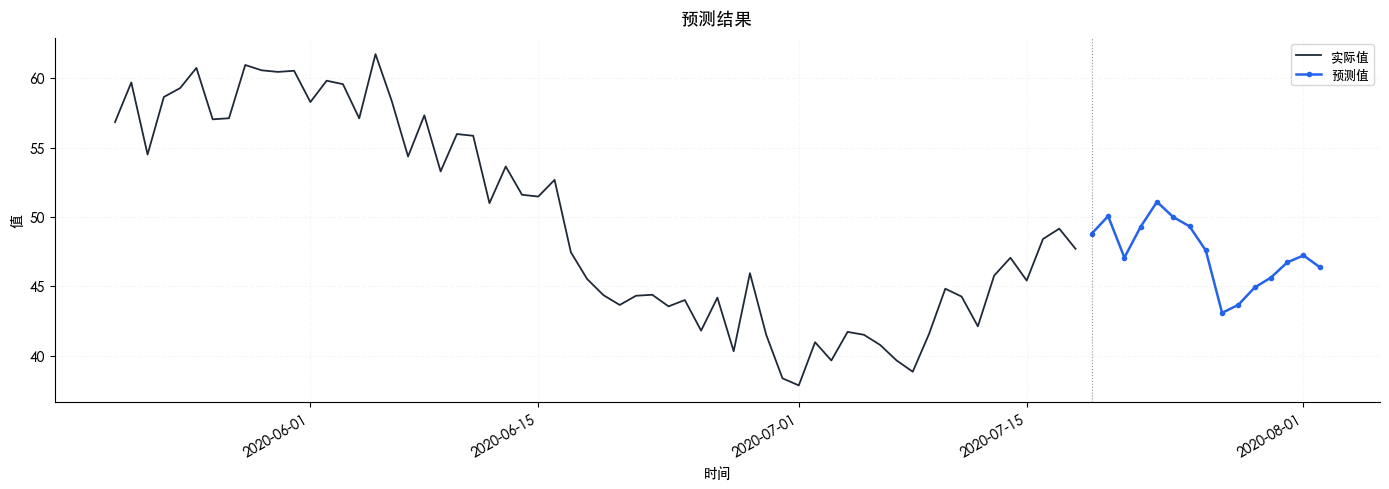

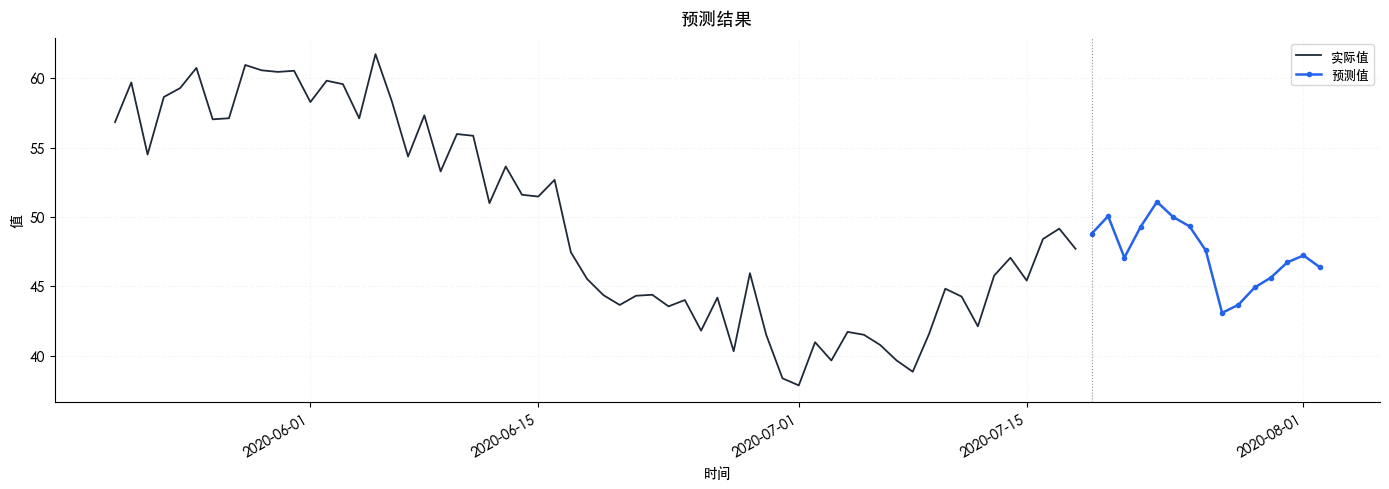

In [38]:
# One-line forecast plot / 一行预测图
router_cov.plot(n=15, history_tail=60, lang='zh')

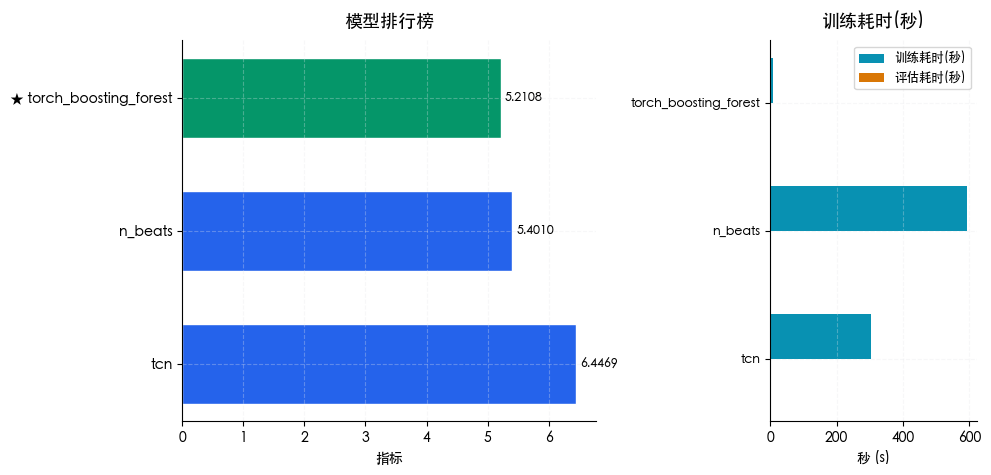

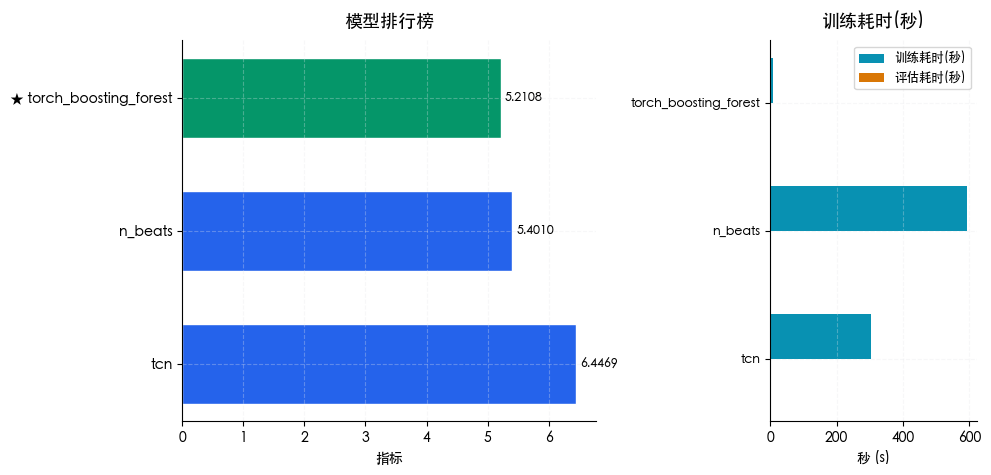

In [39]:
# Leaderboard / 排行榜
router_cov.plot_leaderboard(lang='zh')

In [40]:
# Incremental update / 增量更新
new_data = pd.DataFrame({
    'date': pd.date_range('2020-07-19', periods=30, freq='D'),
    'value': 50 + 10 * np.sin(np.linspace(6*np.pi, 7*np.pi, 30)) + np.random.randn(30)*2
})

router.update(new_data)
print("After SmartRouter update / SmartRouter 更新后:")
router.predict(5).head()


2026-02-15 23:41:49 - ModelPipeline - INFO -   Updated: n_beats


After SmartRouter update / SmartRouter 更新后:


,date,value
0,2020-08-18,53.266610
1,2020-08-19,52.406881
2,2020-08-20,53.969021
3,2020-08-21,52.946493
4,2020-08-22,53.955260


## 27. Full Production Example / 完整生产示例

A real-world pattern: high-quality fit → predict → save → load → incremental update.

一个真实生产模式：高质量拟合 → 预测 → 保存 → 加载 → 增量更新。

In [41]:
from PipelineTS.pipeline import SmartRouter
from PipelineTS.dataset import LoadElectricDataSets

# 1. Load real data / 加载真实数据
electric = LoadElectricDataSets()
electric['date'] = pd.to_datetime(electric['date'])
print(f"Electric dataset: {electric.shape}")

# 2. Smart routing with high quality preset / 智能路由 + 高质量预设
router_prod = SmartRouter(
    time_col='date',
    target_col='value',
    preset='fast',               # Use 'high_quality' for production / 生产环境用 'high_quality'
    quantile=0.9,                # 90% prediction intervals / 90% 预测区间
    time_limit=60,               # 1-minute budget / 1 分钟预算
)
router_prod.fit(electric)

# 3. Review what SmartRouter decided / 查看 SmartRouter 的决策
print(f"\nStrategy / 策略:")
print(f"  Models / 模型: {router_prod.strategy_['models']}")
print(f"  Lags / 滞后: {router_prod.strategy_['lags']}")
print(f"  Ensemble / 集成: {router_prod.ensemble_}")

# 4. Predict / 预测
forecast = router_prod.predict(n=12)
print(f"\nForecast shape / 预测形状: {forecast.shape}")
forecast.head()


2026-02-15 23:41:49 - SmartRouter - INFO - Preset 'fast': max_models=3, cv=3, search=basic, ensemble=none
2026-02-15 23:41:49 - SmartRouter - INFO - Accelerator: MPS
2026-02-15 23:41:49 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 23:41:49 - SmartRouter - INFO -   [RouteStep 1/4] 📊 Data Profiling                   0.0s
2026-02-15 23:41:49 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 23:41:49 - SmartRouter - INFO -   Rows: 397  |  Freq: MS  |  Regular: True
  Stationarity: non_stationary (d=1)
  Trend: 0.695  |  Seasonality: 0.686  |  Noise: 0.553
  Autocorr(1): 0.863  |  Autocorr(2): 0.636  |  CV: 0.173
  Seasonalities: 2  |  Regime changes: 121
  Missing: 0.0%  |  Outliers: 0.0%  |  Has negative: False  Dominant periods: [6, 12]
2026-02-15 23:41:49 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 23:41:49 - SmartRouter - INFO -   [RouteStep

Electric dataset: (397, 2)



2026-02-15 23:43:42 - ModelPipeline - INFO -   => n_beats: metric=5.518753, train=108.89s, eval=0.56s, quantile_acc=0.833
2026-02-15 23:43:42 - ModelPipeline - WARNING - Time budget exhausted after 112.8s. Skipping 2 remaining model(s): ['tide', 'torch_boosting_forest']
2026-02-15 23:43:42 - ModelPipeline - INFO - 
Training complete: 1 succeeded, 0 failed, 2 skipped (112.8s total)
2026-02-15 23:43:42 - ModelPipeline - INFO - 
  Rank  Model                       train_cost(s)    eval_cost(s)       Metric     QAcc 
  --------------------------------------------------------------------------------------
 *1    n_beats                       108.8879       0.5598       5.5188       0.8333 
2026-02-15 23:43:42 - ModelPipeline - INFO - Best model: n_beats (metric=5.518753)
2026-02-15 23:43:42 - SmartRouter - INFO - ════════════════════════════════════════════════════════════
2026-02-15 23:43:42 - SmartRouter - INFO -   [RouteStep 4/4] ✅ Evaluation & Summary           113.0s
2026-02-15 23:43:


Strategy / 策略:
  Models / 模型: ['n_beats', 'tide', 'torch_boosting_forest']
  Lags / 滞后: 12
  Ensemble / 集成: None

Forecast shape / 预测形状: (12, 4)


,date,value,value_lower,value_upper
0,2018-02-01,111.462080,102.939012,118.857640
1,2018-03-01,107.435396,99.816832,113.831246
2,2018-04-01,94.650249,86.045449,101.056292
3,2018-05-01,96.746130,88.132608,103.214108
4,2018-06-01,107.259238,98.734320,113.985729


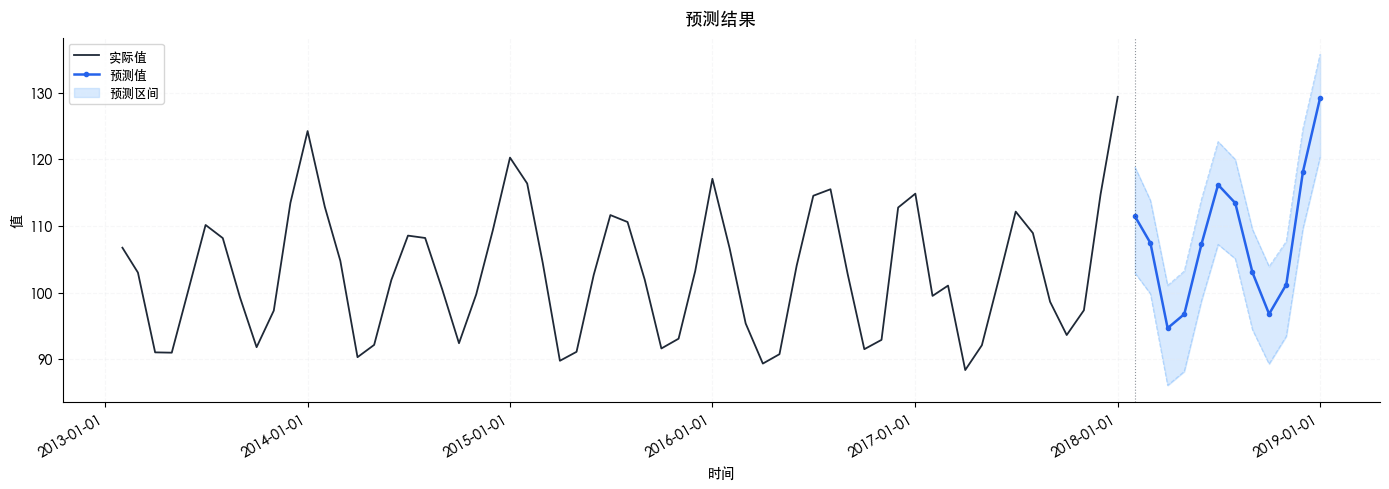

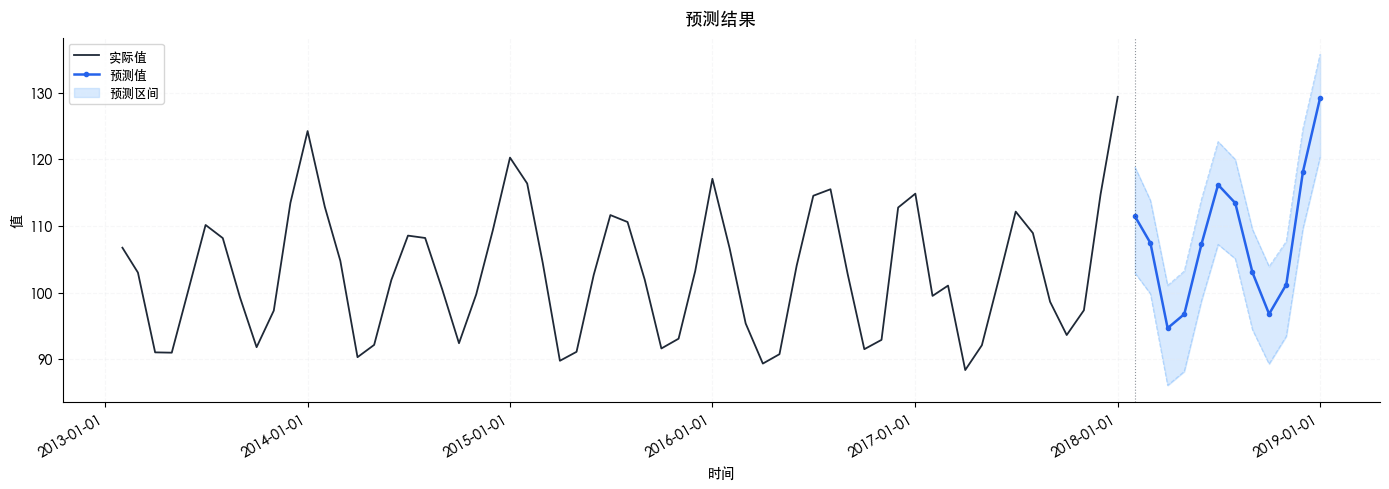

In [42]:
# 5. Visualize / 可视化
router_prod.plot(n=12, history_tail=60, lang='zh')

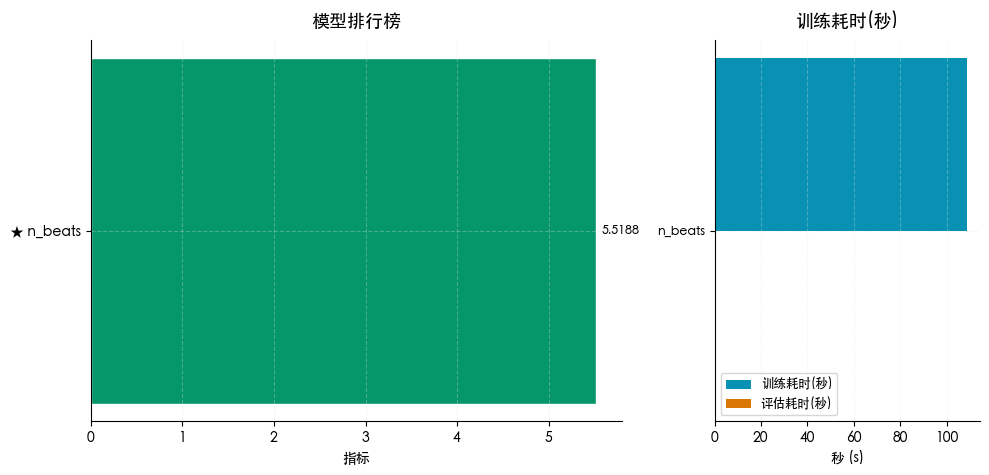

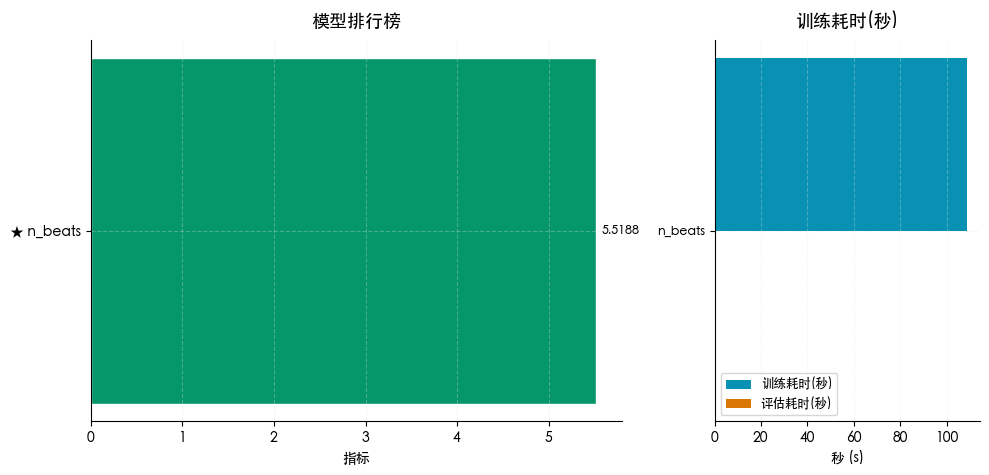

In [43]:
router_prod.plot_leaderboard(lang='zh')

## Summary / 总结

### ModelPipeline vs SmartRouter / 对比

| Feature / 功能 | ModelPipeline | SmartRouter |
|---|---|---|
| **User control / 用户控制** | Full manual control / 完全手动控制 | Automatic (can override) / 自动（可覆盖） |
| **Model selection / 模型选择** | User specifies / 用户指定 | Data-driven scoring / 数据驱动评分 |
| **Model pinning / 模型指定** | `include_models` filters model list / 筛选模型列表 | `include_models` pins models, skips heuristic selection / 指定模型，跳过启发式选择 |
| **Preprocessing / 预处理** | User provides scaler / 用户提供缩放器 | Auto-selected / 自动选择 |
| **Lags / 滞后窗口** | User specifies / 用户指定 | Auto-explored / 自动探索 |
| **Hyperparameters / 超参数** | Manual / `__` syntax / 手动 | Auto-tuned (HPO) / 自动调优 |
| **Ensemble / 集成** | No | Yes (5 strategies) / 是（5 种策略） |
| **Best for / 最适合** | Expert users, custom workflows / 专家用户 | Quick starts, production / 快速启动、生产环境 |

### Key Parameters / 关键参数

**ModelPipeline:**
| Parameter / 参数 | Description / 描述 |
|---|---|
| `lags` | Input window size / 输入窗口 |
| `include_models` | `'light'`, `'ml'`, `'nn'`, `'all'`, or list / 模型集合 |
| `quantile` | Coverage level for intervals / 区间覆盖水平 |
| `id_col` | Panel data identifier / 面板数据标识 |
| `known_covariates` / `past_covariates` | External features / 外部特征 |
| `time_limit` | Time budget in seconds / 时间预算 |
| `cv` | Cross-validation folds / 交叉验证折数 |

**SmartRouter (additional):**
| Parameter / 参数 | Description / 描述 |
|---|---|
| `preset` | `'fast'`, `'medium_quality'`, `'high_quality'`, `'best_quality'` |
| `include_models` | Pin specific models (str or list); skips heuristic selection / 指定模型（字符串或列表）；跳过启发式选择 |
| `ensemble_strategy` | `'auto'`, `'weighted_avg'`, `'median'`, `'stacking'`, `'multi_stack'`, `'none'` |
| `ensemble_top_k` | Max models in ensemble / 集成最大模型数 |
| `search_strategy` | `'basic'`, `'auto'`, `'thorough'` |
| `hpo_strategy` | `'none'`, `'quick'`, `'full'` |
| `max_models` | Max candidate models / 最大候选模型数 |